In [1]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')          
SEED = 42
df = pd.read_csv("../data/q1_heart_disease.csv")
print(df.shape)
print(df.dtypes)
print(df.isna().sum())
df.head() 

(800, 12)
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


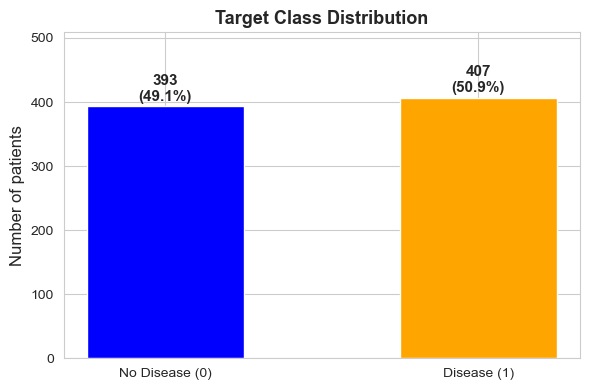

No Disease (0): 393 patients  (49.1%)
Disease    (1): 407 patients  (50.9%)


In [2]:
#PLOT 1: Target Class Distribution
counts = df['heart_disease'].value_counts().sort_index()
labels = ['No Disease (0)', 'Disease (1)']
colors = ['Blue', 'Orange']
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts.values, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, counts.values):
    pct = val / counts.sum() * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 8,                              
        f"{val}\n({pct:.1f}%)",              
        ha='center', fontsize=11, fontweight='bold'
    )

ax.set_ylabel('Number of patients', fontsize=12)
ax.set_title('Target Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylim(0, counts.max() * 1.25)

plt.tight_layout()
plt.show()

print(f"No Disease (0): {counts[0]} patients  ({counts[0]/len(df)*100:.1f}%)")
print(f"Disease    (1): {counts[1]} patients  ({counts[1]/len(df)*100:.1f}%)")

### Interpretation — Target Class Distribution

The two classes are nearly balanced:
- **407 patients (50.9%)** have no heart disease (class 0)
- **393 patients (49.1%)** have heart disease (class 1)

Correlation with heart_disease (strongest first):
exercise_angina    0.290
age                0.289
oldpeak            0.172
sex                0.140
resting_bp         0.116
cholesterol        0.056
max_hr            -0.022
fasting_bs        -0.004
Name: heart_disease, dtype: float64



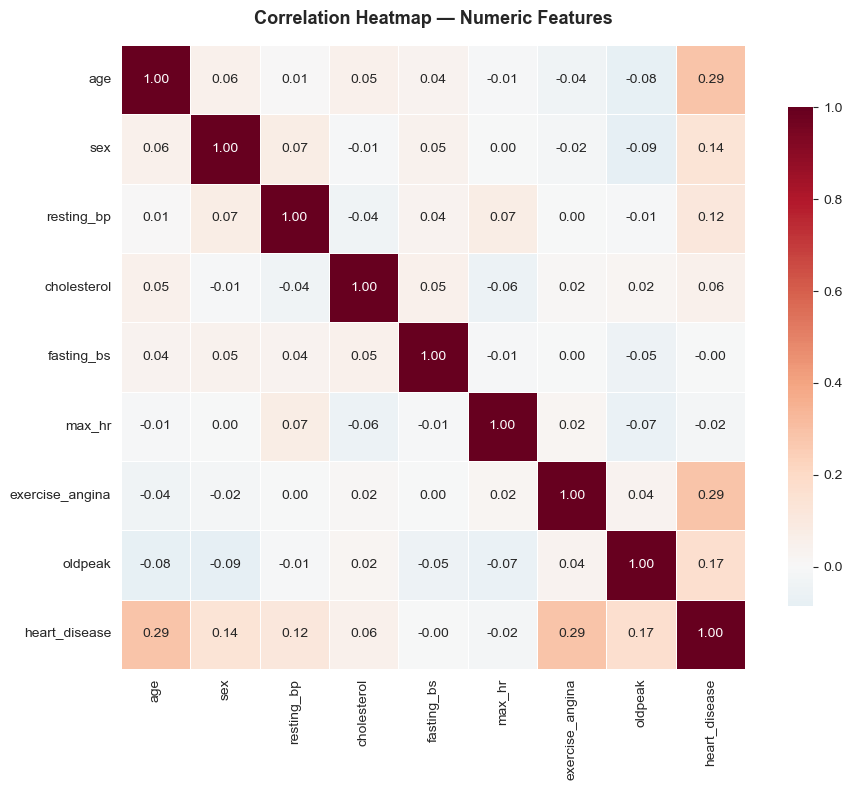

In [3]:
# PLOT 2: Correlation Heatmap
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
target_corr = corr_matrix['heart_disease'].drop('heart_disease').sort_values(key=abs, ascending=False)
print("Correlation with heart_disease (strongest first):")
print(target_corr.round(3))
print()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax
)

ax.set_title('Correlation Heatmap — Numeric Features',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

### Interpretation — Correlation Heatmap

Looking at the `heart_disease` row, the strongest relationships are:

- **exercise_angina (+0.29):** Chest pain during exercise is the strongest
  numeric predictor of heart disease
- **age (+0.29):** Older patients are more likely to have heart disease
- **oldpeak (+0.17):** Greater ST depression after exercise suggests disease
- **sex (+0.14):** There is a moderate difference between male and female patients
- **resting_bp (+0.12):** Higher resting blood pressure is mildly predictive

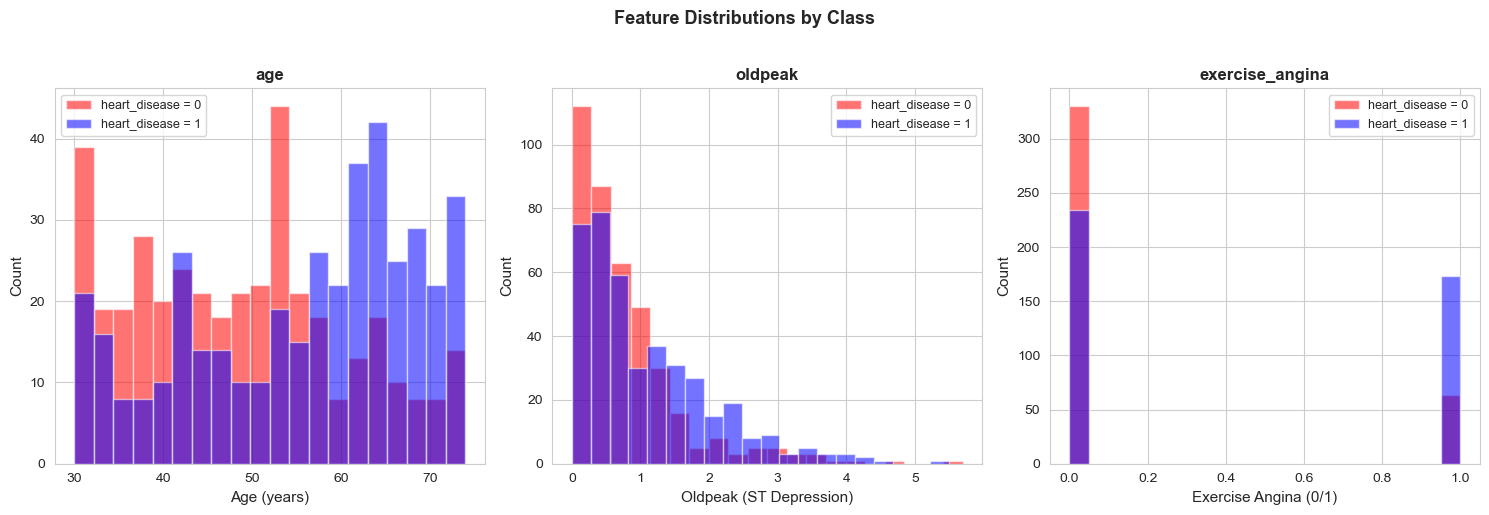

In [4]:
#PLOT 3: Feature Distributions split by class
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

features    = ['age', 'oldpeak', 'exercise_angina']
feat_labels = ['Age (years)', 'Oldpeak (ST Depression)', 'Exercise Angina (0/1)']
colors_map  = {0: 'Red', 1: 'Blue'}

for ax, feat, label in zip(axes, features, feat_labels):
    for cls in [0, 1]:
        subset = df[df['heart_disease'] == cls][feat].dropna()
        ax.hist(
            subset,
            bins=20,
            alpha=0.55,
            color=colors_map[cls],
            label=f'heart_disease = {cls}',
            edgecolor='white'
        )
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{feat}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle('Feature Distributions by Class',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Interpretation — Feature Distributions by Class

- **Age:** Patients *with* disease (orange) skew towards older ages (50s–70s),
  while healthy patients (blue) are more spread across younger ages.
  Age is a useful predictor but not decisive — there is a lot of overlap.

- **Oldpeak:** Healthy patients are tightly clustered near 0 (little ST depression),
  while diseased patients spread to higher values. This clean separation makes
  oldpeak one of the most informative numeric features.

- **Exercise Angina:** This is a binary feature (0 = no pain, 1 = pain during exercise).
  Diseased patients disproportionately report exercise angina — the bar heights
  confirm it is the strongest individual predictor in the numeric feature set.

These findings confirm what the heatmap showed — exercise_angina, oldpeak,
and age are the features we expect the models to rely on most.

In [5]:
#Separate X (features) and y (target)
# X = everything the model uses to make predictions (all columns except target)
# y = what we are trying to predict (heart_disease column)

X = df.drop(columns=['heart_disease'])
y = df['heart_disease']

print(f"X shape : {X.shape}   → 800 patients, 11 features each")
print(f"y shape : {y.shape}  → 800 labels (0 or 1)")
print()

categorical_cols = ['chest_pain_type', 'resting_ecg', 'st_slope']
numeric_cols     = [c for c in X.columns if c not in categorical_cols]

print(f"Numeric columns    : {numeric_cols}")
print(f"Categorical columns: {categorical_cols}")

X shape : (800, 11)   → 800 patients, 11 features each
y shape : (800,)  → 800 labels (0 or 1)

Numeric columns    : ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak']
Categorical columns: ['chest_pain_type', 'resting_ecg', 'st_slope']


In [6]:
#Split into Train and Test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Training set : {X_train.shape[0]} rows")
print(f"Test set     : {X_test.shape[0]} rows")
print()
print("Class balance in TRAINING set:")
print(y_train.value_counts(normalize=True).round(3))
print()
print("Class balance in TEST set:")
print(y_test.value_counts(normalize=True).round(3))

Training set : 640 rows
Test set     : 160 rows

Class balance in TRAINING set:
heart_disease
1    0.509
0    0.491
Name: proportion, dtype: float64

Class balance in TEST set:
heart_disease
1    0.506
0    0.494
Name: proportion, dtype: float64


In [7]:
#Handling Missing Values
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train[numeric_cols] = imputer.fit_transform(X_train[numeric_cols])

X_test[numeric_cols] = imputer.transform(X_test[numeric_cols])

print("Medians learned from training data:")
for col, median in zip(numeric_cols, imputer.statistics_):
    print(f"  {col:20s} → {median:.1f}")

print()
print(f"Missing values remaining in train : {X_train.isna().sum().sum()}")
print(f"Missing values remaining in test  : {X_test.isna().sum().sum()}")

Medians learned from training data:
  age                  → 53.0
  sex                  → 1.0
  resting_bp           → 130.0
  cholesterol          → 248.0
  fasting_bs           → 0.0
  max_hr               → 149.0
  exercise_angina      → 0.0
  oldpeak              → 0.7

Missing values remaining in train : 0
Missing values remaining in test  : 0


In [8]:
X_train_enc = pd.get_dummies(X_train, columns=categorical_cols, drop_first=False)
X_test_enc  = pd.get_dummies(X_test,  columns=categorical_cols, drop_first=False)

X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print(f"Columns BEFORE encoding : {X_train.shape[1]}")
print(f"Columns AFTER encoding  : {X_train_enc.shape[1]}")
print()
print("New columns created:")
new_cols = [c for c in X_train_enc.columns if c not in X_train.columns]
for c in new_cols:
    print(f"  {c}")

Columns BEFORE encoding : 11
Columns AFTER encoding  : 18

New columns created:
  chest_pain_type_asymptomatic
  chest_pain_type_atypical_angina
  chest_pain_type_non_anginal
  chest_pain_type_typical_angina
  resting_ecg_left_ventricular_hypertrophy
  resting_ecg_normal
  resting_ecg_st_t_wave_abnormality
  st_slope_down
  st_slope_flat
  st_slope_up


In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_enc[numeric_cols] = scaler.fit_transform(X_train_enc[numeric_cols])

X_test_enc[numeric_cols]  = scaler.transform(X_test_enc[numeric_cols])

print("After scaling — training set numeric column stats:")
print(X_train_enc[numeric_cols].agg(['mean', 'std']).round(2))
print()
print(f"Final training matrix shape : {X_train_enc.shape}")
print(f"Final test matrix shape     : {X_test_enc.shape}")

After scaling — training set numeric column stats:
      age  sex  resting_bp  cholesterol  fasting_bs  max_hr  exercise_angina  \
mean -0.0  0.0        -0.0         -0.0        -0.0     0.0              0.0   
std   1.0  1.0         1.0          1.0         1.0     1.0              1.0   

      oldpeak  
mean      0.0  
std       1.0  

Final training matrix shape : (640, 18)
Final test matrix shape     : (160, 18)


**scaled all numeric columns** using StandardScaler so
that every feature has a mean of 0 and a standard deviation of 1.
This prevents features with large values like cholesterol from
dominating features with small values like oldpeak.

Throughout all of this, the imputer and scaler were fitted on
**training data only** and then applied to the test set

In [10]:
#TASK 4: Training Three Classification Models
from sklearn.tree     import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'Decision Tree'    : DecisionTreeClassifier(random_state=42),
    'Random Forest'    : RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}

fitted_models = {}
for name, model in models.items():
    model.fit(X_train_enc, y_train)
    fitted_models[name] = model
    print(f"{name} trained")

print()
print("All three models trained. None have seen the test set yet.")

Decision Tree trained
Random Forest trained
Gradient Boosting trained

All three models trained. None have seen the test set yet.


### Model Training

Three tree-based classifiers were trained on the 640-row training set.

A **Decision Tree** was the simplest of the three — it works by splitting
the data into yes/no questions at each step, like a flowchart.

A **Random Forest** was used to address this problem. Instead of one tree,
100 trees were built — each on a slightly different random sample of the
data. Their predictions were then combined by majority vote.

**Gradient Boosting** was the most sophisticated of the three. Trees were
built one at a time, with each new tree focused specifically on the mistakes
left behind by the previous ones.

All three models were fixed with `random_state=42` to ensure the results
are reproducible.

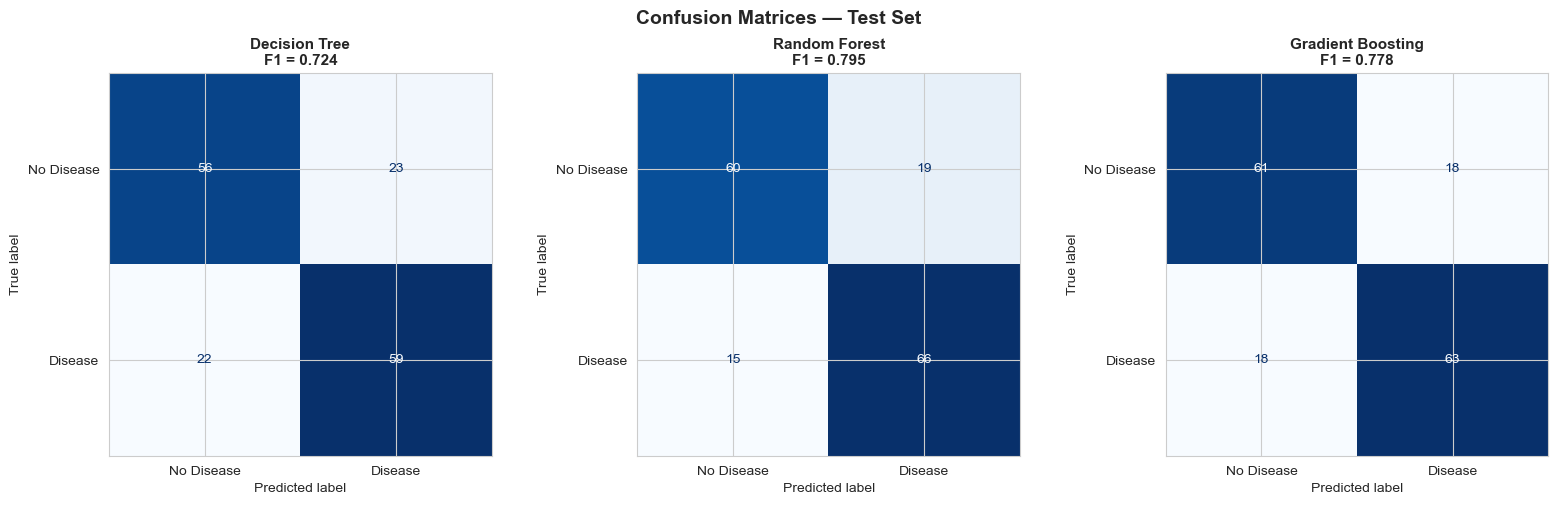

Test-set performance — all three models


                   Accuracy  Precision  Recall      F1
Model                                                 
Decision Tree        0.7188     0.7195  0.7284  0.7239
Random Forest        0.7875     0.7765  0.8148  0.7952
Gradient Boosting    0.7750     0.7778  0.7778  0.7778

Best model by F1 : Random Forest


In [11]:
#TASK 5: Evaluating All Three Models
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    f1_score, accuracy_score, ConfusionMatrixDisplay
)

results_list = []

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')

for ax, (name, model) in zip(axes, fitted_models.items()):

    y_pred = model.predict(X_test_enc)

    acc  = accuracy_score (y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score   (y_test, y_pred)
    f1   = f1_score       (y_test, y_pred)

    results_list.append({
        'Model'    : name,
        'Accuracy' : acc,
        'Precision': prec,
        'Recall'   : rec,
        'F1'       : f1,
    })

    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Disease'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nF1 = {f1:.3f}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results_list).set_index('Model').round(4)
print("Test-set performance — all three models")
print("\n")
print(results_df.to_string())
print()
print(f"Best model by F1 : {results_df['F1'].idxmax()}")

### Model Evaluation — Which model performed best and why?

The Random Forest was the best performing model based on the F1 score
(0.795), outperforming both the Decision Tree (0.724) and Gradient
Boosting (0.778).

Accuracy alone was not used to make this judgement. In a clinical
setting, the cost of a false negative — telling a sick patient they
are healthy — is far greater than the cost of a false alarm. F1 score
was therefore the primary metric because it penalises a model for
both missing disease cases and raising unnecessary alarms.

The Decision Tree had the weakest performance across all metrics. A
single tree grown without any depth limit tends to memorise the
training data, which hurts it when it encounters new patients.

The Gradient Boosting model was competitive but slightly behind the
Random Forest on recall (0.778 vs 0.815). This means the Random
Forest caught more actual disease cases — 66 out of 81 compared to
Gradient Boosting's 63 — which is the most important difference in
a screening context.

The Random Forest was therefore selected as the best model and will
be taken forward to hyperparameter tuning in the next step.

In [12]:
#TASK 6: Hyperparameter Tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators'    : [200, 400],
    'max_depth'       : [6, 10, None],
    'min_samples_leaf': [1, 3, 5],
}

grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42),
    param_grid = param_grid,
    scoring    = 'f1',
    cv         = 5,
    n_jobs     = 1,
    refit      = True,
    verbose    = 1
)

print("Running grid search — 18 combinations × 5 folds = 90 fits...")
grid_search.fit(X_train_enc, y_train)

print("\nBest hyperparameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param:25s} = {value}")
print(f"\nBest cross-validated F1 : {grid_search.best_score_:.4f}")

Running grid search — 18 combinations × 5 folds = 90 fits...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best hyperparameters found:
  max_depth                 = 10
  min_samples_leaf          = 5
  n_estimators              = 200

Best cross-validated F1 : 0.8227


In [13]:
#Compare tuned model vs baseline on the TEST set
tuned_model    = grid_search.best_estimator_
baseline_model = fitted_models['Random Forest']

y_pred_baseline = baseline_model.predict(X_test_enc)
y_pred_tuned    = tuned_model.predict(X_test_enc)

comparison = pd.DataFrame({
    'Baseline (default)': {
        'Accuracy' : accuracy_score (y_test, y_pred_baseline),
        'Precision': precision_score(y_test, y_pred_baseline),
        'Recall'   : recall_score   (y_test, y_pred_baseline),
        'F1'       : f1_score       (y_test, y_pred_baseline),
    },
    'Tuned (GridSearchCV)': {
        'Accuracy' : accuracy_score (y_test, y_pred_tuned),
        'Precision': precision_score(y_test, y_pred_tuned),
        'Recall'   : recall_score   (y_test, y_pred_tuned),
        'F1'       : f1_score       (y_test, y_pred_tuned),
    },
}).round(4)

comparison['Improvement'] = (
    comparison['Tuned (GridSearchCV)'] - comparison['Baseline (default)']
).round(4)

print("Baseline vs Tuned Random Forest — Test Set")
print(comparison.to_string())

Baseline vs Tuned Random Forest — Test Set
           Baseline (default)  Tuned (GridSearchCV)  Improvement
Accuracy               0.7875                0.8125       0.0250
Precision              0.7765                0.8000       0.0235
Recall                 0.8148                0.8395       0.0247
F1                     0.7952                0.8193       0.0241


### Hyperparameter Tuning — Results

GridSearchCV tested 18 combinations of hyperparameters across 5 folds
of the training set (90 fits in total), optimising for F1 score.

The best configuration found was `max_depth=10`, `min_samples_leaf=5`,
and `n_estimators=200`. Compared to the default Random Forest, the
tuned model improved on every metric on the test set — F1 rose from
0.795 to 0.819, accuracy from 0.788 to 0.813, and recall from 0.815
to 0.840.

The most meaningful gain was in recall. The tuned model correctly
identified more actual disease cases — missing fewer sick patients
than the baseline. 